In [1]:
#pip install pandas numpy matplotlib seaborn

In [2]:
#pip install scikit-learn

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# --- STEP 1: Create a Training Dataset ---
# 
# Features:
# - Goal: 1 = Short-term, 2 = Long-term
# - RiskProfile (Target): 0 = Low, 1 = Medium, 2 = High
'''data = {
    'Age': [16, 25, 40, 18, 22, 50, 65, 19, 30, 35, 17, 28, 45, 60, 21],
    'Goal': [1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2],
    'MonthlySavings': [20, 100, 300, 50, 150, 500, 200, 80, 120, 250, 40, 90, 400, 150, 130],
    'RiskProfile': [0, 1, 2, 0, 1, 2, 0, 1, 1, 2, 0, 1, 2, 0, 1]
}'''
df=pd.read_csv('financial_dummy_dataset.csv')
#df = pd.DataFrame(data)
print("--- [1] Training Data Loaded ---")
print(df.head(10))

--- [1] Training Data Loaded ---
   Age  Goal  MonthlySavings (INR)  RiskProfile
0   56     1                 21616            1
1   46     2                 48864            0
2   32     1                 33797            1
3   60     3                 19842            0
4   25     1                 27990            2
5   38     1                 20475            2
6   56     1                 27223            1
7   36     1                 23779            0
8   40     3                 13265            0
9   28     3                 47178            2



--- [2] DATA CLEANING & EXPLORATION (EDA) ---
-> Missing values check: 0 total missing values.

-> Data Types:
Age                     int64
Goal                    int64
MonthlySavings (INR)    int64
RiskProfile             int64
dtype: object

-> Descriptive Statistics:
                       count       mean           std    min       25%  \
Age                   1000.0     40.986     13.497852   18.0     29.00   
Goal                  1000.0      1.995      0.818318    1.0      1.00   
MonthlySavings (INR)  1000.0  26008.978  14007.851974  625.0  13600.75   
RiskProfile           1000.0      0.980      0.829631    0.0      0.00   

                          50%       75%      max  
Age                      42.0     52.00     64.0  
Goal                      2.0      3.00      3.0  
MonthlySavings (INR)  26932.5  37808.75  49992.0  
RiskProfile               1.0      2.00      2.0  

-> Risk Profile Distribution (0=Low, 1=Medium, 2=High):
RiskProfile
0    354
2    334
1    312
Name

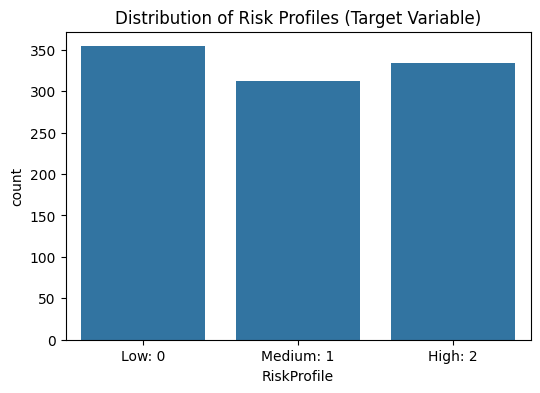


-> Correlation with Target ('RiskProfile'):
RiskProfile             1.000000
Goal                   -0.007520
MonthlySavings (INR)   -0.037013
Age                    -0.064117
Name: RiskProfile, dtype: float64


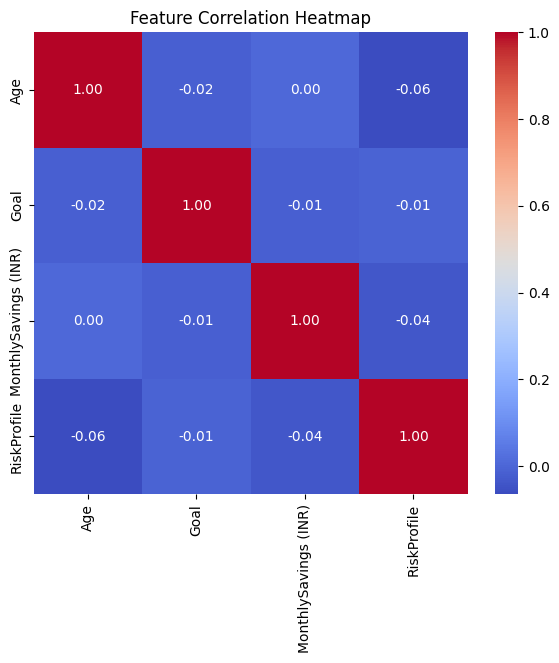

,Age,Goal,MonthlySavings (INR),RiskProfile
0,56,1,21616,1
1,46,2,48864,0
2,32,1,33797,1
3,60,3,19842,0
4,25,1,27990,2
...,...,...,...,...
995,22,2,37227,0
996,40,3,46451,2
997,27,3,23169,0
998,61,2,5932,1


In [5]:
# --- STEP 2: cleaning data: checking for null values
def clean_and_explore_data(df):
    """Performs essential data cleaning checks and exploratory data analysis (EDA)."""
    
    print("\n--- [2] DATA CLEANING & EXPLORATION (EDA) ---")
    
    # 2.1 CLEANING: Check for missing data (important for real datasets)
    missing = df.isnull().sum().sum()
    print(f"-> Missing values check: {missing} total missing values.")
    
    # 2.2 PREPROCESSING: Check data types (ensuring no unexpected 'Object' types)
    print("\n-> Data Types:")
    print(df.dtypes)
    
    # 2.3 EXPLORATION: Descriptive Statistics
    print("\n-> Descriptive Statistics:")
    print(df.describe().T)
    
    # 2.4 EXPLORATION: Target Distribution (Checking for class imbalance)
    print("\n-> Risk Profile Distribution (0=Low, 1=Medium, 2=High):")
    print(df['RiskProfile'].value_counts())

    # --- NEW VISUALIZATION 1: TARGET DISTRIBUTION ---
    plt.figure(figsize=(6, 4))
    sns.countplot(x='RiskProfile', data=df)
    plt.title('Distribution of Risk Profiles (Target Variable)')
    plt.xticks([0, 1, 2], ['Low: 0', 'Medium: 1', 'High: 2'])
    plt.show()
    

    # 2.4 EXPLORATION: Feature Correlation (Printed text)
    print("\n-> Correlation with Target ('RiskProfile'):")
    print(df.corr()['RiskProfile'].sort_values(ascending=False))

    # --- NEW VISUALIZATION 2: CORRELATION HEATMAP ---
    plt.figure(figsize=(7, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Feature Correlation Heatmap')
    plt.show()
    
    return df

clean_and_explore_data(df)

In [6]:
# --- STEP 3: Define Features (X) and Target (y) ---
# X = The "questions" (Age, Goal, Savings)
# y = The "answer" (RiskProfile)
features = ['Age', 'Goal', 'MonthlySavings (INR)']
target = 'RiskProfile'

X = df[features]
y = df[target]

In [7]:
# --- STEP 4: Split Data into Training and Testing ---
# The model 'studies' with the training data and
# takes an 'exam' with the testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# --- STEP 5: Scale the Features (Very Important!) ---
# We scale data so 'Age' (e.g., 50) and 'Goal' (e.g., 2)
# are treated equally by the model.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use the same scaler

In [9]:
# --- STEP 6: Create and Train the ML Model (k-NN) ---
# We'll tell it to look at its 3 nearest neighbors.
print("\n--- [2] Training the ML 'Brain' (k-NN Model) ---")
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)
print("ML Model is trained and ready!")


--- [2] Training the ML 'Brain' (k-NN Model) ---
ML Model is trained and ready!


In [10]:
# --- STEP 7: Check Model Accuracy ---
# Let's see how well our model did on the 'exam' (test data)
y_pred = knn_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")
# Note: With a tiny dataset, accuracy might be low. In real life,
# we'd use thousands of data points.

Model Accuracy on Test Data: 35.00%


In [11]:
def visualize_knn_prediction(X_scaled_all, y_all, new_point_scaled, predicted_code):
    """
    Creates a 3D scatter plot to show the ML decision boundary.
    """
    
    # 1. Setup the 3D Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    plt.title(f"k-NN Classification: New Client (Predicted: {['Low', 'Medium', 'High'][predicted_code]})")
    
    # Define labels for the plot legend
    target_names = ['Low (0)', 'Medium (1)', 'High (2)']
    colors = ['green', 'orange', 'red']
    
    # 2. Plot all Training Data Points (the 'Memory' of the model)
    for i, target_name in enumerate(target_names):
        # Select all points belonging to this risk class
        subset = X_scaled_all[y_all == i]
        
        ax.scatter(subset[:, 0], subset[:, 1], subset[:, 2], 
                   c=colors[i], label=target_name, s=50, alpha=0.6)
    
    # 3. Plot the NEW Client Data Point (the 'Prediction')
    ax.scatter(new_point_scaled[:, 0], new_point_scaled[:, 1], new_point_scaled[:, 2], 
               c='blue', marker='*', s=300, label='New Client Prediction')
    
    # 4. Set Labels and Legend
    ax.set_xlabel('Age (Scaled)')
    ax.set_ylabel('Goal Duration (Scaled)')
    ax.set_zlabel('Monthly Savings (Scaled)')
    ax.legend()
    
    # Show the plot
    plt.show()



In [12]:
# --- STEP 7: Build the User-Facing Advisor ---

def get_user_input():
    print("\n\n" + "="*50)
    print(" Welcome to the Realistic Risk Assessor!")
    print("="*50)
    
    # 1. Age (Essential demographic data)
    age = int(input("What is your current age? (e.g., 35): "))
    
    # 2. Goal (Time Horizon)
    print("\nWhat is the primary time horizon for this investment goal?")
    print("  1. Short-term (1-5 years, e.g., car or down payment)")
    print("  2. Long-term (5+ years, e.g., retirement or college fund)")
    goal_choice = int(input("Enter 1 for Short-term or 2 for Long-term: "))
    
    # 3. Risk Tolerance (Realistic ML Input Feature)
    print("\nOn a scale of 1 to 10, how comfortable are you with seeing your portfolio fall?")
    print("  (1 = Panic and sell immediately; 10 = See it as a buying opportunity)")
    risk_tolerance = int(input("Enter your Risk Tolerance Score (1-10): "))

    # 4. Monthly Savings (Used only for portfolio calculation)
    monthly_savings = int(input("\nWhat is your realistic monthly investment/savings amount? $: "))
    
    # The return order aligns with the ML features (Age, Goal, Risk_Tolerance) 
    # and the value needed for the final portfolio calculation (monthly_savings).
    return age, goal_choice, risk_tolerance, monthly_savings

In [13]:
def get_recommendation(profile_code, savings):
    # Map the ML code to a friendly name.
    profile_names = ['Low_Risk', 'Medium_Risk', 'High_Risk']
    profile = profile_names[profile_code]
    
    plan = {}
    advice = ""
    
    # Use realistic asset categories for modern portfolio theory
    
    if profile == "Low_Risk":
        plan = {
            "Government Bonds (Safe)": 0.50 * savings,
            "High-Yield Savings/Money Market": 0.30 * savings,
            "Diversified Bond ETFs": 0.20 * savings
        }
        advice = "Your profile is 'Low Risk'. The best plan is to preserve capital. Focus on safety and liquidity."
    
    elif profile == "Medium_Risk":
        plan = {
            "Total Stock Market ETFs": 0.40 * savings,
            "Corporate Bond Funds": 0.30 * savings,
            "Real Estate Investment Trusts (REITs)": 0.15 * savings,
            "Cash Reserve": 0.15 * savings
        }
        advice = "Your profile is 'Medium Risk'. We recommend a balanced approach for steady growth and moderate protection against volatility."
    
    elif profile == "High_Risk":
        plan = {
            "Individual Growth Stocks/Tech ETFs": 0.55 * savings,
            "International Emerging Market ETFs": 0.25 * savings,
            "Broad Index Funds (Low Cost)": 0.10 * savings,
            "Commodities/Alternative Assets": 0.10 * savings
        }
        advice = "Your profile is 'High Risk'! This aggressive plan focuses on maximum capital appreciation and is best suited for a long time horizon."
        
    return profile, plan, advice

def show_final_results(profile, plan, advice, monthly_savings):
    print("\n" + "="*50)
    print("YOUR PROFESSIONAL ML PLAN IS READY!")
    print("="*50)
    
    print(f"\nBased on our ML analysis, you have been classified as a **{profile}** profile.")
    print(f"\nHere is your suggested allocation for your **{monthly_savings:.2f}**/month:")
    
    # Display the plan with professional asset names
    for item, amount in plan.items():
        print(f"  -> {item}: **{amount:.2f}**")
        
    print(f"\n---  Our Professional Advice  ---\n{advice}")



 Welcome to the Realistic Risk Assessor!

What is the primary time horizon for this investment goal?
  1. Short-term (1-5 years, e.g., car or down payment)
  2. Long-term (5+ years, e.g., retirement or college fund)

On a scale of 1 to 10, how comfortable are you with seeing your portfolio fall?
  (1 = Panic and sell immediately; 10 = See it as a buying opportunity)


c:\Users\Jash\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


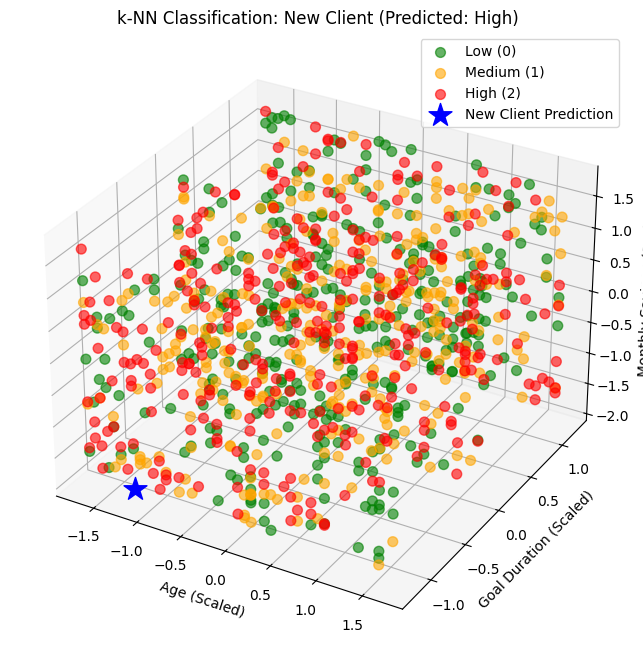


YOUR PROFESSIONAL ML PLAN IS READY!

Based on our ML analysis, you have been classified as a **High_Risk** profile.

Here is your suggested allocation for your **60.00**/month:
  -> Individual Growth Stocks/Tech ETFs: **33.00**
  -> International Emerging Market ETFs: **15.00**
  -> Broad Index Funds (Low Cost): **6.00**
  -> Commodities/Alternative Assets: **6.00**

---  Our Professional Advice  ---
Your profile is 'High Risk'! This aggressive plan focuses on maximum capital appreciation and is best suited for a long time horizon.


In [14]:
# --- This is the main part of the program ---
if __name__ == "__main__":
       
       
    # 1. Get user data
    user_age, user_goal, user_savings, original_savings = get_user_input()
    
    # 2. Prepare data for ML prediction
    new_user_data = np.array([[user_age, user_goal, user_savings]])
    
    # 3. Scale the user's data (using the fitted scaler)
    new_user_data_scaled = scaler.transform(new_user_data)
    
    # 4. ML PREDICTION
    predicted_profile_code = knn_model.predict(new_user_data_scaled)[0]
    
    # 5. VISUALIZE the prediction point in context
    # Prepare the full scaled dataset for plotting reference
    X_scaled_full = scaler.transform(X) # Use X (full features) defined globally
    y_full = y.to_numpy() # Use y (full labels) defined globally

    visualize_knn_prediction(X_scaled_full, y_full, new_user_data_scaled, predicted_profile_code)
    
    # 6. Get the matching recommendation
    profile_name, plan, advice = get_recommendation(predicted_profile_code, original_savings)
    
    # 7. Show the final results
    show_final_results(profile_name, plan, advice, original_savings)